# **Deep learning approach**

In [39]:
# dependencies installation
!pip install ultralytics opencv-python pytesseract

In [46]:
# package update
!sudo apt update
!sudo apt install -y tesseract-ocr

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [75.2 kB]
Err:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages
  File has unexpected size (77498 != 75166). Mirror sync in progress? [IP: 13.35.238.79 443]
  Hashes of expected file:
   - Filesize:75166 [weak]
   - SHA512:a82e1668c3c59175af932384c3828caf8d8ece3e3cfd75d40d19a6e35108bdcdde04a4512c2344a2cd0d35a7bc11d63050707a76703f54ebd01de05833633507
   - SHA256:fbc2a9ca752211719f5b62f6f3983e3555d0112daa1bf7f41685e112e969e635
   - MD5Sum:efe1285a86fbf411358141ff0439cd09 [weak]
  Release file created at: Sun, 04 Ma

In [40]:
# importing dependencies
import cv2
import pytesseract
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

In [41]:
# ---------- Preprocess for OCR ----------
def preprocess_for_ocr(cropped_img):
    gray = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    resized = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    return resized

In [43]:
# Load YOLO model (YOLOv8n pretrained on COCO by default)
model = YOLO("yolov8n.pt")
# OCR config
custom_config = r'--oem 3 --psm 6'

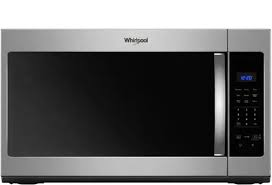

In [44]:
# Load image
image_path = "/content/drive/MyDrive/Colab_Notebooks/objects/whirlpool.jpg"
image = cv2.imread(image_path)

# Display
cv2_imshow(image)

In [47]:
# ---------- Object Detection + OCR ----------
results = model(image_path)
for result in results:
    for box in result.boxes:
        cls = model.names[int(box.cls)]
        conf = float(box.conf)

        if conf > 0.5:
            print(f"\n🔍 Detected object: {cls} (confidence: {conf:.2f})")

            # Crop detected object
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cropped = image[y1:y2, x1:x2]

            # Apply OCR
            processed = preprocess_for_ocr(cropped)
            text = pytesseract.image_to_string(processed, config=custom_config).lower().strip()

            print("📝 OCR Text Detected:\n", text if text else "No readable text found.")


image 1/1 /content/drive/MyDrive/Colab_Notebooks/objects/whirlpool.jpg: 448x640 1 tv, 1 microwave, 9.5ms
Speed: 4.4ms preprocess, 9.5ms inference, 3.3ms postprocess per image at shape (1, 3, 448, 640)

🔍 Detected object: microwave (confidence: 0.90)
📝 OCR Text Detected:
 al


# **API approach**

In [56]:
# Installation of dependencies
!pip install google-generativeai

In [57]:
# Import necessary dependencies
import google.generativeai as genai
from PIL import Image
import IPython.display as display
import os
from google.colab import userdata

In [58]:
# Configure API key and initialize model
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = userdata.get('api_key')

os.environ['GOOGLE_API_KEY']=userdata.get('api_key')
model = genai.GenerativeModel(model_name="models/gemini-1.5-pro")

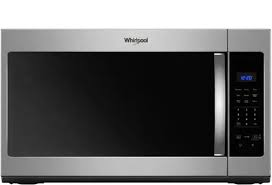

In [67]:
# Load image
image_path = "/content/drive/MyDrive/Colab_Notebooks/objects/whirlpool.jpg"
img = Image.open(image_path)
display.display(img)

In [68]:
# Prompt Gemini to analyze objects and text
prompt = """
You are an AI assistant. Analyze the image and list:
1. Detected object.
2. All visible text within the object.
"""

# Make the multimodal call
response = model.generate_content([prompt, img])

# Show the response
print(response.text)

1. **Detected object:** Microwave oven

2. **Visible text:**

* **Whirlpool** (Brand logo)
* **3:00** (Time display - likely a default and not permanently printed)
* **Add 30 Sec** (Button label)


# **Transformer based approach**

In [48]:
# 📦 Installation of dependencies
!pip install -q transformers timm torchvision accelerate

In [49]:
# ✅ dependencies import
import torch
import torchvision.transforms as T
import cv2
from PIL import Image
import numpy as np
from transformers import DetrImageProcessor, DetrForObjectDetection
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [50]:
# ✅ Load DETR for object detection
detr_processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
detr_model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

# ✅ Load TrOCR for text recognition
trocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-stage1")
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

# ✅ Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
detr_model.to(device)
trocr_model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/4.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linea

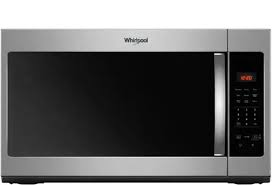

In [91]:
# ✅ Load and display image
image_path = "/content/drive/MyDrive/Colab_Notebooks/objects/whirlpool.jpg"
image = Image.open(image_path).convert("RGB")
cv2_imshow(np.array(image))

In [92]:
# ✅ Object detection using DETR
inputs = detr_processor(images=image, return_tensors="pt").to(device)
outputs = detr_model(**inputs)

# Postprocess
target_sizes = torch.tensor([image.size[::-1]], device=device)
results = detr_processor.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]

# Visual inspection & OCR
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    class_name = detr_model.config.id2label[label.item()]
    score_val = round(score.item(), 3)
    print(f"\n🔍 DETR Detected: {class_name} ({score_val})")

    # Get bounding box
    box = [int(b.item()) for b in box]
    x1, y1, x2, y2 = box

    # Crop and show
    cropped = image.crop((x1, y1, x2, y2))

    # OCR with TrOCR
    inputs_ocr = trocr_processor(images=cropped, return_tensors="pt").to(device)
    with torch.no_grad():
        generated_ids = trocr_model.generate(**inputs_ocr)
        text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    print("📝 OCR Text:", text if text else "No text detected.")



🔍 DETR Detected: microwave (0.999)
📝 OCR Text: . . . . .
